# Autoencoder reconstruction comparison

Compare the released MLP autoencoder with the mixed-baseline CNN on paired test examples. The published test split contains 3,066 PubMed, 79 Nilearn, and 202 NeuroVault maps. Because full PubMed reconstruction is slow on a typical Mac, this notebook evaluates the first 200 PubMed examples and the complete Nilearn and NeuroVault splits. Set `DOMAIN_LIMITS["pubmed"] = None` to run the complete PubMed test split. Set `INCLUDE_FINETUNED = True` only when you explicitly want the domain-fine-tuned CNN branches.

The provider downloads the published root-level split JSONLs and shared volume tensor from Hugging Face. Legacy local paths stored in individual JSONL rows are metadata only and are never loaded.

This is the `paired_atlas_free` protocol. Older PubMed MLP autoencoder comparisons loaded the MLP-native PubMed image resource and selected a different first-N cohort, while the CNN used atlas-free rows. Those older values are valid for their native cohort but are not expected to match this notebook. Here both families receive the same examples; the MLP bridge converts each shared volume to its established masker flat-map representation.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from neurovlm import AtlasFreeCNNDataProvider, load_pipeline
from neurovlm.evaluation import (
    default_comparison_matrix,
    evaluate_reconstruction_comparison,
)

DOMAINS = ("pubmed", "nilearn", "neurovault")
DOMAIN_LIMITS = {
    "pubmed": 200,       # runtime-conscious default; use None for all 3,066
    "nilearn": None,     # complete test split: 79
    "neurovault": None,  # complete test split: 202
}
INCLUDE_FINETUNED = False  # explicit opt-in
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EVALUATION_SCOPE = "PubMed first 200; Nilearn and NeuroVault complete test splits"


## Run the comparison

The shared volume payload is about 4.2 GB and is downloaded once into the normal Hugging Face cache. Later providers reuse the cached payload.

In [2]:
results = []
for domain in DOMAINS:
    selections = default_comparison_matrix(
        "autoencoder",
        domains=(domain,),
        include_finetuned=INCLUDE_FINETUNED,
    )
    provider = AtlasFreeCNNDataProvider(
        domain=domain,
        limit=DOMAIN_LIMITS[domain],
    )
    results.append(evaluate_reconstruction_comparison(
        selections=selections,
        provider=provider,
        device=DEVICE,
    ))

summary = pd.DataFrame(row for result in results for row in result.summary)
by_source = pd.DataFrame(row for result in results for row in result.by_source)
by_sample = pd.DataFrame(row for result in results for row in result.by_sample)
manifest = pd.DataFrame(row for result in results for row in result.manifest)

summary.sort_values(["evaluation_domain", "family", "variant"])


,model_id,family,task,domain,variant,evaluation_domain,status,comparison_protocol,comparison_space,n,...,top10_overlap,top10_target_recall,top1_dice,top1_intersection_voxels,top1_overlap,top1_target_recall,top5_dice,top5_intersection_voxels,top5_overlap,top5_target_recall
5,cnn_autoencoder_mixed_baseline_eval_neurovault,cnn,autoencoder,None,mixed_baseline,neurovault,resolved,paired_atlas_free,native_atlas_free_volume,202,...,0.550961,0.550961,0.471101,290.198020,0.471101,0.471101,0.521068,1603.846535,0.521068,0.521068
4,mlp_autoencoder_eval_neurovault,mlp,autoencoder,None,default,neurovault,resolved,paired_atlas_free,mlp_masker_flatmap,202,...,0.213515,0.213515,0.064668,18.495050,0.064668,0.064668,0.132443,189.128713,0.132443,0.132443
3,cnn_autoencoder_mixed_baseline_eval_nilearn,cnn,autoencoder,None,mixed_baseline,nilearn,resolved,paired_atlas_free,native_atlas_free_volume,79,...,0.124388,0.124388,0.257377,158.544304,0.257377,0.257377,0.105070,323.405063,0.105070,0.105070
2,mlp_autoencoder_eval_nilearn,mlp,autoencoder,None,default,nilearn,resolved,paired_atlas_free,mlp_masker_flatmap,79,...,0.194471,0.194471,0.289944,82.924051,0.289944,0.289944,0.197807,282.468354,0.197807,0.197807
1,cnn_autoencoder_mixed_baseline_eval_pubmed,cnn,autoencoder,None,mixed_baseline,pubmed,resolved,paired_atlas_free,native_atlas_free_volume,200,...,0.505145,0.505145,0.609529,375.470000,0.609529,0.609529,0.575856,1772.485000,0.575856,0.575856
0,mlp_autoencoder_eval_pubmed,mlp,autoencoder,None,default,pubmed,resolved,paired_atlas_free,mlp_masker_flatmap,200,...,0.363461,0.363461,0.049703,14.215000,0.049703,0.049703,0.240700,343.720000,0.240700,0.240700


## Aggregate metric plots

CNN metrics are computed in native atlas-free volume space; MLP metrics are computed in the established masker flat-map space. The plots compare complete pipelines in their declared spaces, not voxel-identical representations. Lower reconstruction MSE is better; higher spatial correlation and top-5% Dice are better.

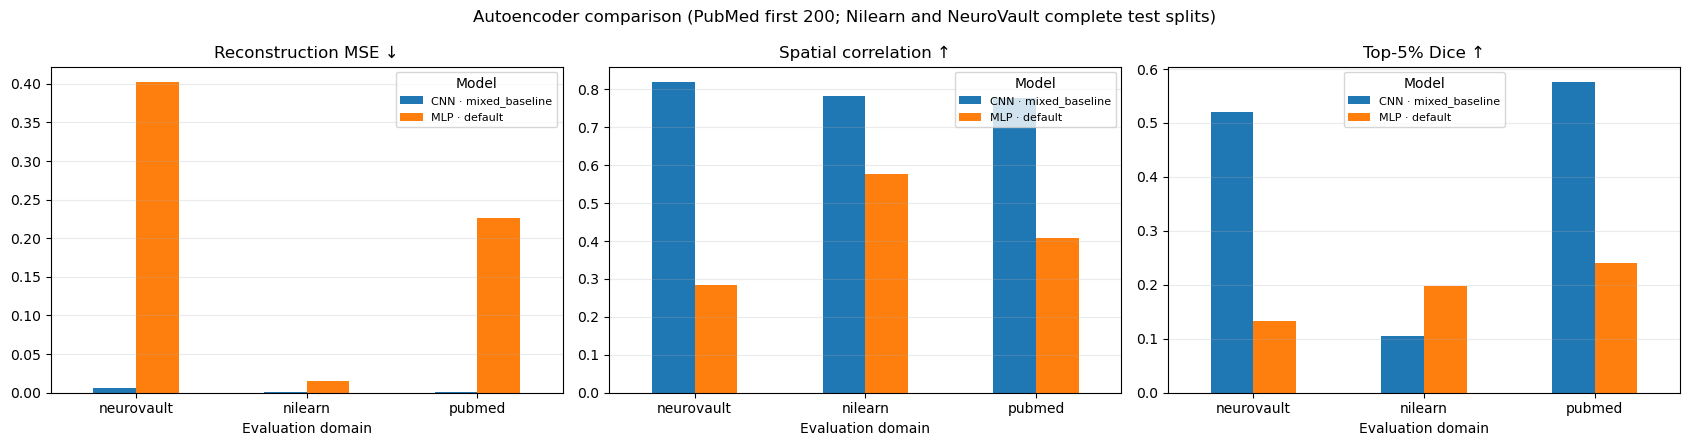

In [3]:
resolved = summary[(summary["status"] == "resolved") & (summary["n"] > 0)].copy()
if resolved.empty:
    raise RuntimeError("No models resolved. Inspect `manifest` for checkpoint errors.")
resolved["model"] = resolved.apply(
    lambda row: f'{row["family"].upper()} · {row["variant"]}', axis=1
)

metrics = (
    ("reconstruction_mse", "Reconstruction MSE ↓"),
    ("spatial_corr", "Spatial correlation ↑"),
    ("top5_dice", "Top-5% Dice ↑"),
)
fig, axes = plt.subplots(1, len(metrics), figsize=(17, 4.5))
for ax, (metric, title) in zip(axes, metrics):
    table = resolved.pivot(index="evaluation_domain", columns="model", values=metric)
    table.plot.bar(ax=ax, rot=0)
    ax.set_title(title)
    ax.set_xlabel("Evaluation domain")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Model", fontsize=8)
fig.suptitle(f"Autoencoder comparison ({EVALUATION_SCOPE})")
fig.tight_layout()
plt.show()


## Per-sample distributions

These box plots expose variance hidden by the aggregate means.

/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_87627/1146578088.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=group_names, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_87627/1146578088.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=group_names, showmeans=True)


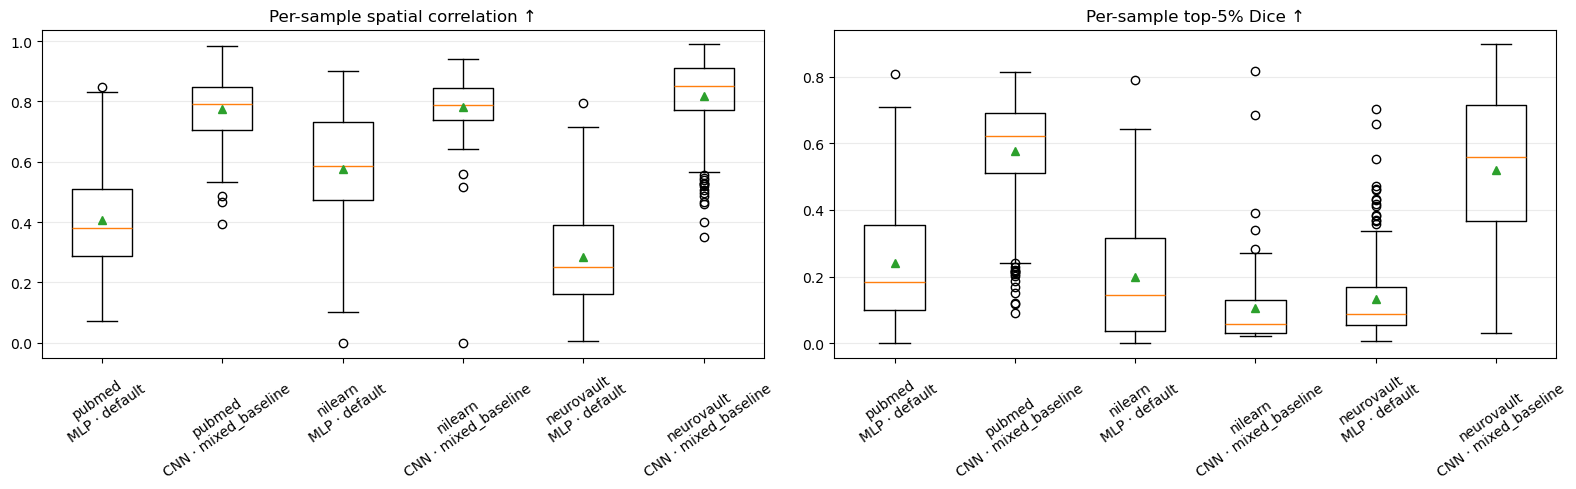

In [4]:
samples = by_sample.copy()
samples["model"] = samples.apply(
    lambda row: f'{row["family"].upper()} · {row["variant"]}', axis=1
)
samples["group"] = samples["evaluation_domain"] + "\n" + samples["model"]
group_names = list(dict.fromkeys(samples["group"]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric, title in (
    (axes[0], "spatial_corr", "Per-sample spatial correlation ↑"),
    (axes[1], "top5_dice", "Per-sample top-5% Dice ↑"),
):
    values = [samples.loc[samples["group"] == name, metric].dropna() for name in group_names]
    ax.boxplot(values, labels=group_names, showmeans=True)
    ax.set_title(title)
    ax.tick_params(axis="x", labelrotation=35)
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


## Qualitative CNN reconstructions

The next three cells show three examples per domain. All-zero maps are skipped—this matters for Nilearn because some very small atlas parcels disappear during 4 mm resampling/cropping. For every non-empty example, the sagittal, coronal, or axial plane with the greatest input activation is selected. Input, reconstruction, and error use independent robust color scales so sparse Nilearn parcels and lower-amplitude reconstructions remain visible; compare spatial structure rather than color magnitude across panels.

In [5]:
cnn = load_pipeline(family="cnn", task="autoencoder", device=DEVICE)
VISUAL_EXAMPLES_PER_DOMAIN = 3
PLANE_NAMES = ("sagittal", "coronal", "axial")

def _first_nonempty_examples(domain, count=VISUAL_EXAMPLES_PER_DOMAIN):
    data = AtlasFreeCNNDataProvider(domain=domain).test
    examples = []
    skipped = 0
    for index in range(len(data)):
        example = data[index]
        if int(torch.count_nonzero(example["volume"])) == 0:
            skipped += 1
            continue
        examples.append(example)
        if len(examples) == count:
            break
    if len(examples) != count:
        raise RuntimeError(f"Only {len(examples)} non-empty {domain} examples were available")
    return examples, skipped

def _strongest_plane(volume):
    candidates = []
    for axis, plane_name in enumerate(PLANE_NAMES):
        reduce_dims = tuple(dim for dim in range(3) if dim != axis)
        scores = volume.abs().sum(dim=reduce_dims)
        slice_index = int(scores.argmax())
        candidates.append((float(scores[slice_index]), axis, slice_index, plane_name))
    _, axis, slice_index, plane_name = max(candidates)
    return volume.select(axis, slice_index), axis, slice_index, plane_name

def _robust_positive_max(values):
    positive = values[values > 0]
    if not len(positive):
        return max(float(values.abs().max()), 1e-8)
    return max(float(torch.quantile(positive.float(), 0.99)), 1e-8)

def plot_reconstruction_domain(domain, count=VISUAL_EXAMPLES_PER_DOMAIN):
    examples, skipped = _first_nonempty_examples(domain, count)
    inputs = torch.stack([example["volume"] for example in examples])
    reconstructions = cnn.reconstruct(inputs).cpu()[:, 0]
    metadata = []
    fig, axes = plt.subplots(count, 3, figsize=(13, 4 * count))
    for row_index, (example, reconstruction) in enumerate(zip(examples, reconstructions)):
        truth = example["volume"][0].cpu()
        truth_plane, axis, slice_index, plane_name = _strongest_plane(truth)
        reconstruction_plane = reconstruction.select(axis, slice_index)
        error_plane = (reconstruction_plane - truth_plane).abs()
        panels = (
            (truth_plane, "Input", "hot"),
            (reconstruction_plane, "CNN reconstruction", "hot"),
            (error_plane, "Absolute error", "magma"),
        )
        for ax, (plane, title, cmap) in zip(axes[row_index], panels):
            image = ax.imshow(
                plane.T,
                origin="lower",
                cmap=cmap,
                vmin=0.0,
                vmax=_robust_positive_max(plane),
            )
            ax.set_title(f"Example {row_index + 1} · {title}")
            ax.axis("off")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
        metadata.append({
            "domain": domain,
            "example": row_index + 1,
            "map_id": example["map_id"],
            "plane": plane_name,
            "slice_index": slice_index,
            "all_zero_maps_skipped_before_selection": skipped,
        })
    fig.suptitle(f"{domain.title()} mixed-baseline CNN reconstructions")
    fig.tight_layout()
    plt.show()
    return pd.DataFrame(metadata)


### PubMed: three reconstruction examples

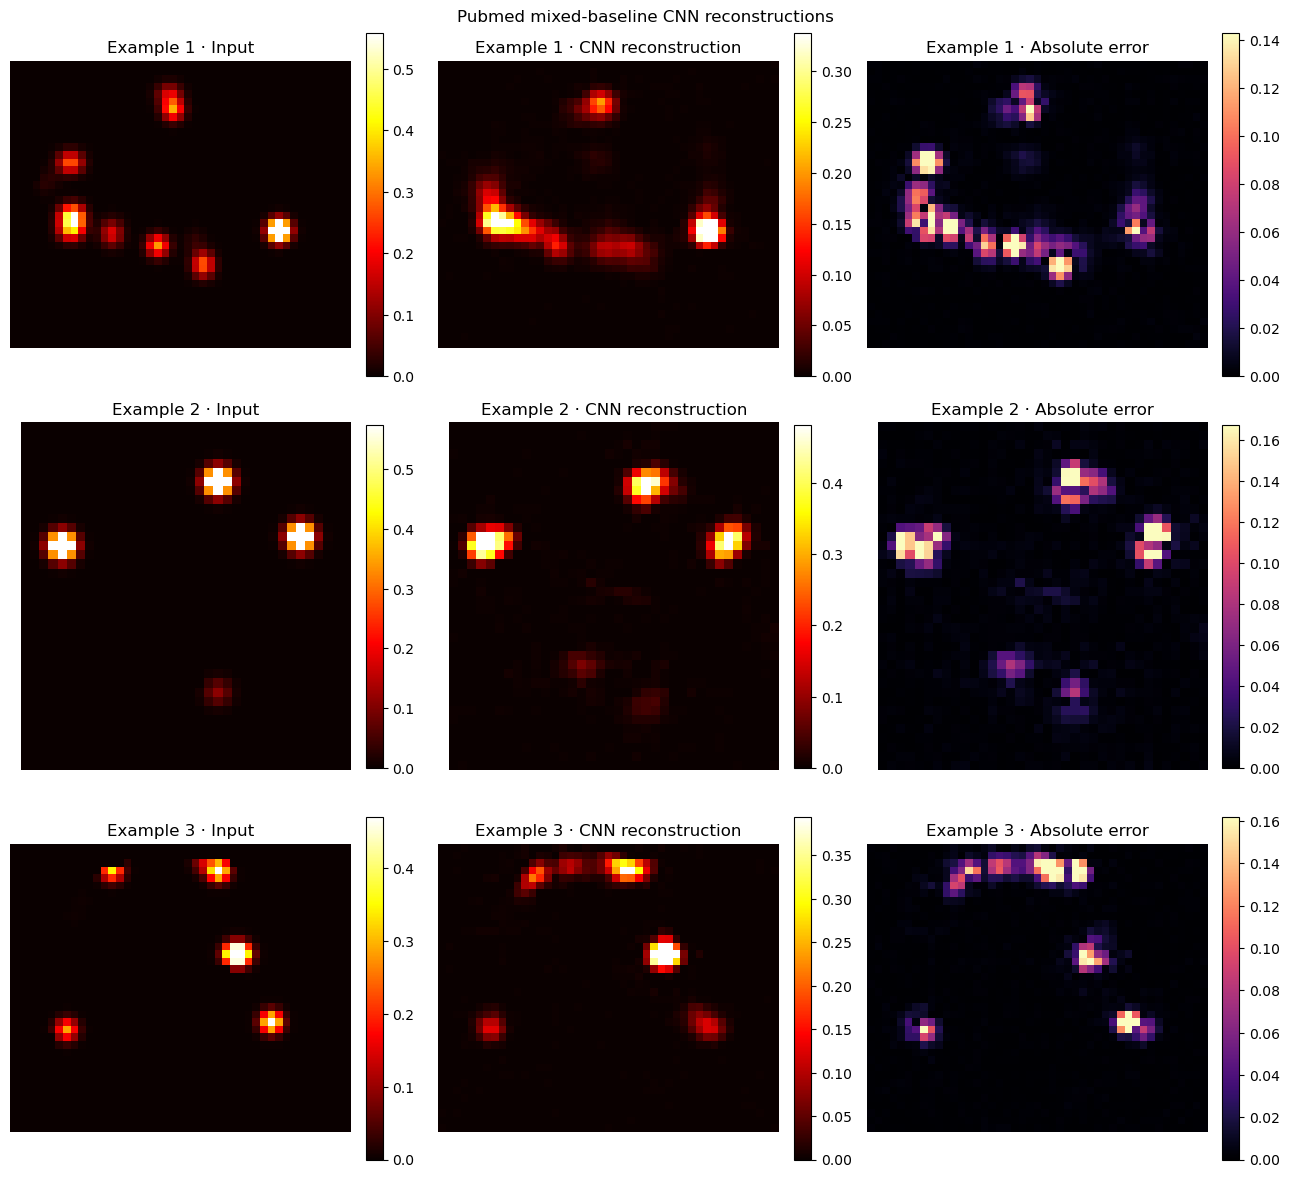

,domain,example,map_id,plane,slice_index,all_zero_maps_skipped_before_selection
0,pubmed,1,pubmed_ale_34173239,sagittal,9,0
1,pubmed,2,pubmed_ale_23418930,coronal,15,0
2,pubmed,3,pubmed_ale_22634217,sagittal,18,0


In [6]:
plot_reconstruction_domain("pubmed")

### Nilearn: three non-empty reconstruction examples

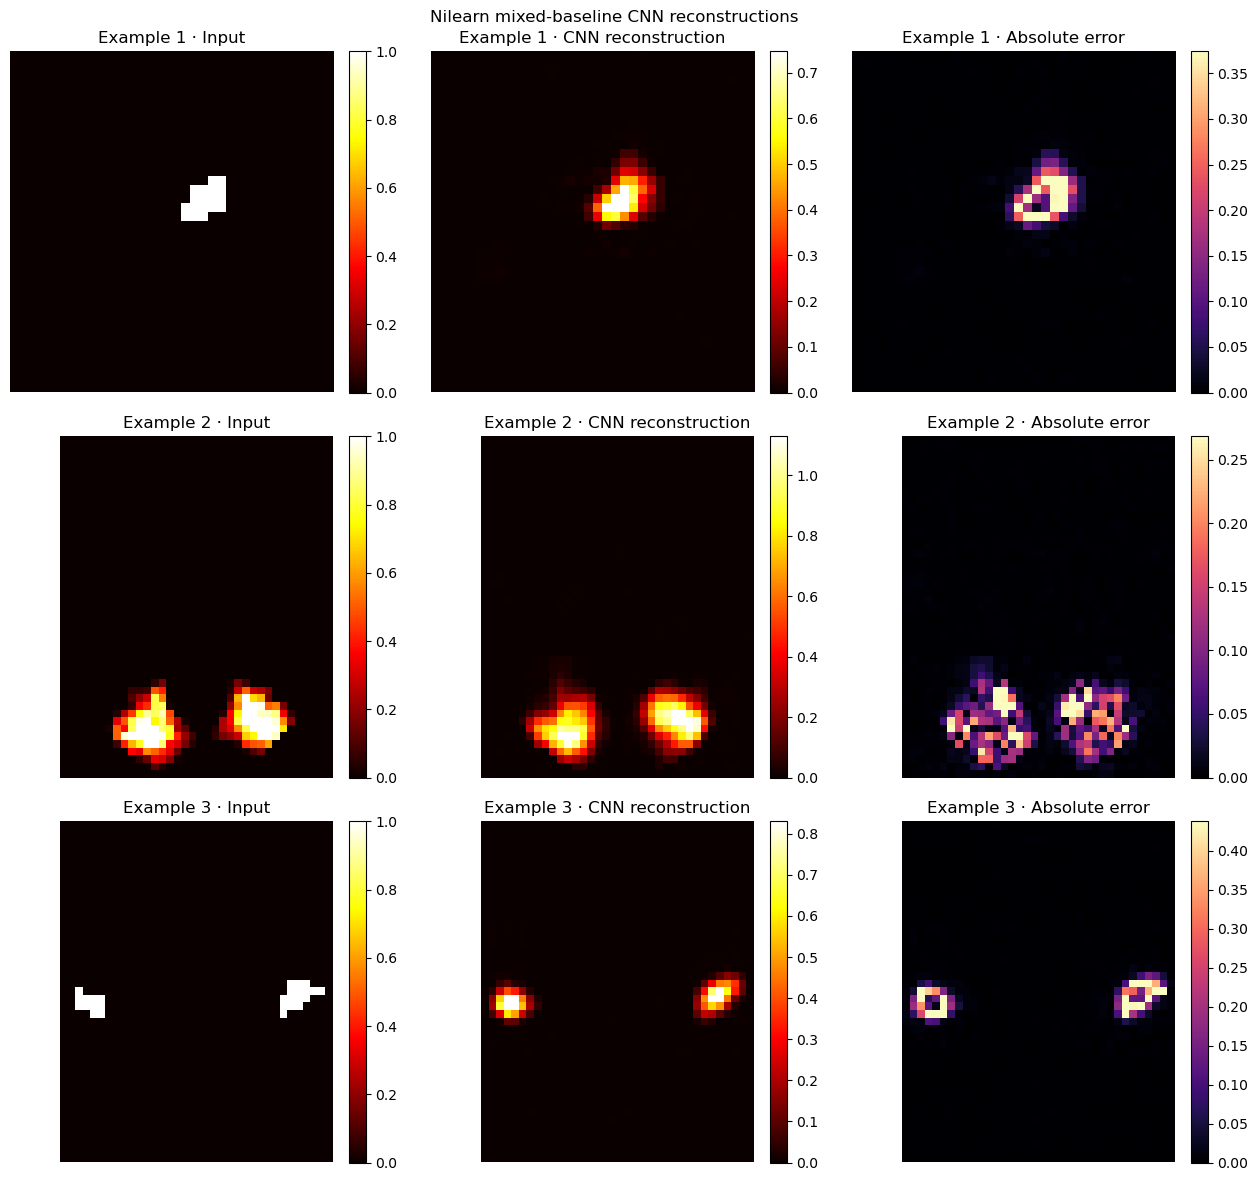

,domain,example,map_id,plane,slice_index,all_zero_maps_skipped_before_selection
0,nilearn,1,nilearn_schaefer_2018_392_7networks_rh_default...,coronal,13,1
1,nilearn,2,nilearn_juelich_probabilistic_51_gm_visual_cor...,axial,14,1
2,nilearn,3,nilearn_juelich_17_gm_inferior_parietal_lobule...,axial,24,1


In [7]:
plot_reconstruction_domain("nilearn")

### NeuroVault: three reconstruction examples

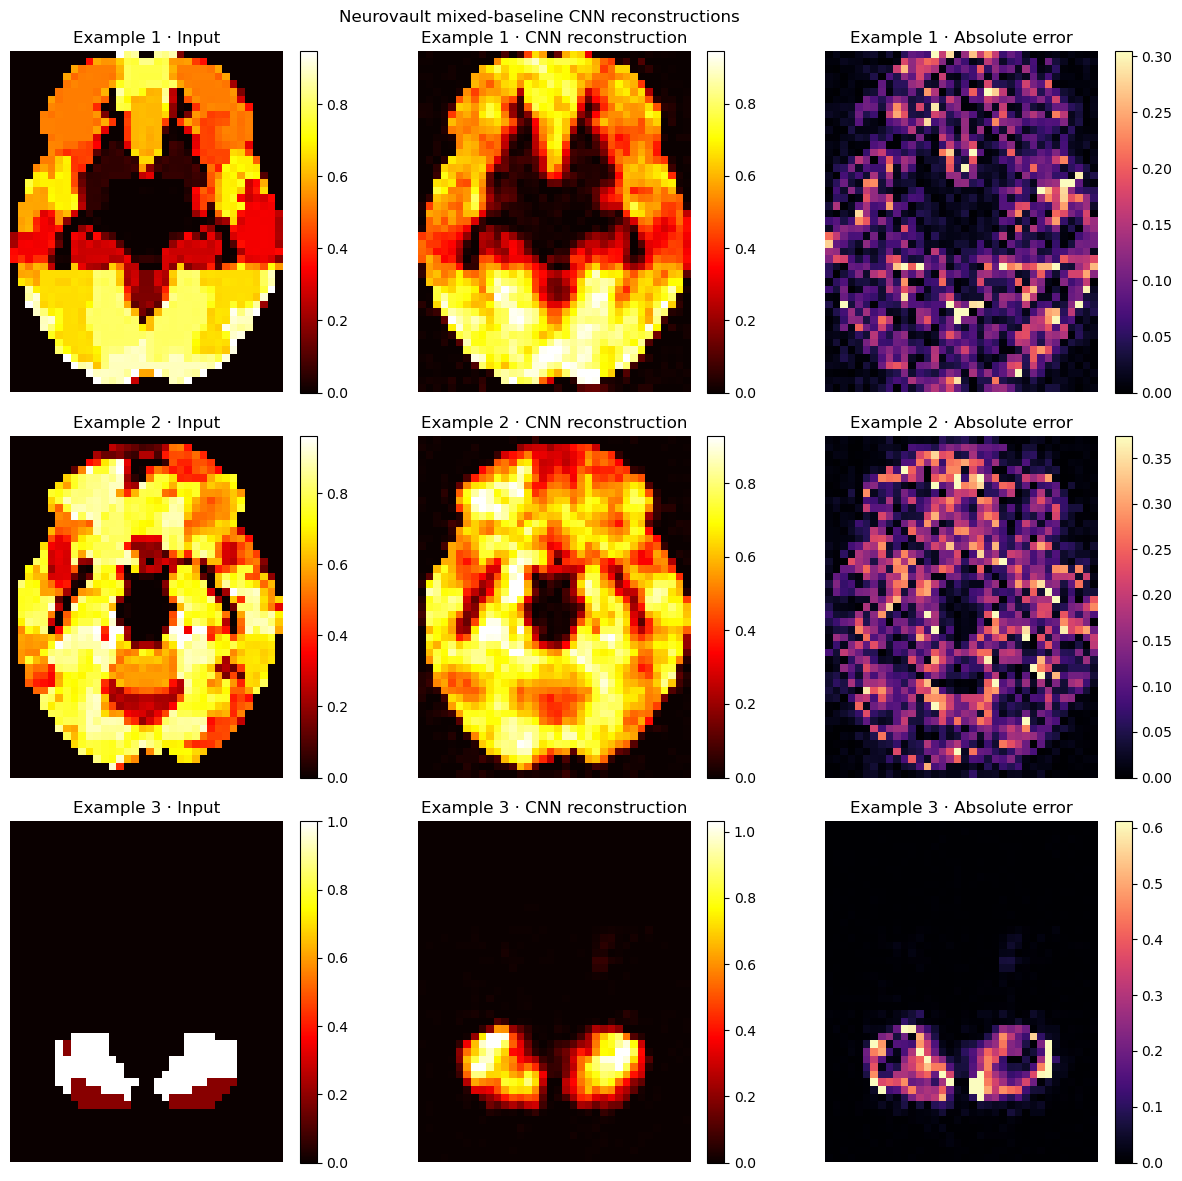

,domain,example,map_id,plane,slice_index,all_zero_maps_skipped_before_selection
0,neurovault,1,neurovault_13877,axial,15,0
1,neurovault,2,neurovault_13883,axial,13,0
2,neurovault,3,neurovault_13894,axial,4,0


In [8]:
plot_reconstruction_domain("neurovault")